# Training Chemical Reaction Networks by Inverse Design

This notebook is the complete, self-contained method behind the paper. It trains a
**chemical reaction network** (CRN) in a continuously stirred tank reactor (CSTR) so that
the steady-state concentration of a chosen *readout* species traces a target function of
the inflow concentration of a chosen *input* species.

What makes this different from a generic function fit is that we never touch rate constants
directly. Every rate is derived from **physically interpretable energetic parameters** —
standard chemical potentials, transition-state energies, and thermodynamic drives — so every
network the optimizer produces is thermodynamically consistent by construction.

**Roadmap**

| § | Contents |
|---|---|
| 1 | The physical model: CSTR mass action and the energetic parameterization |
| 2 | Topology: build a polymerization network from an alphabet and a maximum length |
| 3 | Target library: gaussian, sigmoid, Legendre, trigonometric, quadratic tent |
| 4 | Initialization and freezing: which energetic classes are allowed to train |
| 5 | The numerical method: residual, steady-state solver, implicit gradients, updates |
| 6 | The training loop, with a dashboard that refreshes as it runs |
| 7 | Quasistatic ODE verification and the paper's success criterion |

**Runtime.** The default configuration (`abc3`, 39 species, 60 reactions, 32 grid points) spends
a few seconds in the warm-up solve to JIT-compile, then runs at roughly 0.1–0.4 s per epoch on a
T4 GPU — so the full 16000 epochs is a matter of hours. Per-epoch cost is dominated by the $K$
steady-state solves and the $K$ adjoint solves, so it scales with the grid size and with $N^3$.
If you just want to see the machinery turn over, drop `CONFIG["max_epoch"]` to a few hundred.

**Dependencies.** `jax` (or `jax[cuda]` for GPU use), `diffrax`, `numpy`, `matplotlib`, and `ipykernel` for using the current notebook. 

In [1]:
import jax

# Must precede any array creation. Every result in the paper is float64.
jax.config.update("jax_enable_x64", True)

import time
from itertools import product as iter_product

import diffrax as dfx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from numpy.polynomial import legendre as Leg

%matplotlib inline
plt.ioff()   # figures are never auto-shown; the dashboard manages its own output slot

DASH_RC = {
    "font.size": 7, "axes.titlesize": 8, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 5.5,
    "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 80,
    "axes.titleweight": "bold", "lines.markersize": 3.5,
}
plt.rcParams.update(DASH_RC)

print(f"jax {jax.__version__} | diffrax {dfx.__version__} | numpy {np.__version__}")
print(f"float64 active: {jnp.zeros(1).dtype == jnp.float64}")

jax 0.11.1 | diffrax 0.7.2 | numpy 2.5.2
float64 active: True


## The numerical settings

Everything in the table below is a *published* setting: this single dictionary is the paper's
table of numerical parameters, and nothing further down the notebook hard-codes any of these
numbers. Treat it as fixed unless you are deliberately exploring.

The knobs you are *meant* to turn live in three clearly marked cells further down —
**KNOB A** (network), **KNOB B** (target), **KNOB C** (initialization and freezing).

In [2]:
CONFIG = {
    # ── input grid ────────────────────────────────────────────────────────────
    "K": 32,                    # number of inflow values sampled
    "x_min": 1.0, "x_max": 5.0, # inflow range for the input species

    # ── pseudo-transient continuation (steady-state solver) ───────────────────
    "ptc_dt0": 1e-2,            # initial (and fallback) pseudo-timestep
    "ptc_dt_max": 1e8,          # ceiling on the pseudo-timestep
    "ptc_dt_growth": 2.0,       # max per-step growth factor  (g)
    "ptc_maxiter": 150,         # iteration budget per grid point
    "ptc_atol": 1e-8, "ptc_rtol": 1e-7,
    "c_floor": 1e-15,           # concentration floor inside the PTC update
    "warm_start_floor": 1e-6,   # epoch-0 seed is max(reservoir, this)

    # ── regularizers ──────────────────────────────────────────────────────────
    "lambda_res": 10.0,         # residual penalty          (steady state is a real root)
    "lambda_eig": 1e-2,         # spectral abscissa penalty (that root is stable)
    "spectral_margin": 0.0,
    "lambda_cond": 0.4,         # log-condition penalty     (that root is well conditioned)
    "chi_thresh": 9.0,          # hinge threshold on log10 cond(J)

    # ── trust masking ─────────────────────────────────────────────────────────
    "trust_tol": 1e-6,          # a grid point is trusted if |F|_inf <= this
    "unstable_frac": 0.25,      # abort the run if more than this fraction is untrusted

    # ── Adam ──────────────────────────────────────────────────────────────────
    "lr": 6e-3, "beta1": 0.98, "beta2": 0.999, "adam_eps": 1e-8,
    "grad_clip": 10.0,          # per-class L2 clip

    # ── stopping ──────────────────────────────────────────────────────────────
    "max_epoch": 16000,
    "gnorm_tol": 2e-4,          # stationary point
    "plateau_window": 500,      # relative-loss-change window
    "plateau_tol": 1e-6,

    # ── quasistatic ODE verification ──────────────────────────────────────────
    "ode_t_end": 5e6, "ode_atol": 1e-6, "ode_rtol": 1e-6, "ode_dt0": 1e-2,
    "ode_max_steps": 1_000_000,
    "ode_res_tol": 1e-4,        # per-point convergence: max|F| <= this
    "ode_rmse_tol": 1e-2,       # ODE must agree with the root finder to this RMSE
    "r2_tol": 0.98,             # success threshold on the fit

    # ── logging cadence (display only, no effect on the trained result) ───────
    "log_every": 10,            # solver/gradient-norm history sampling
    "param_every": 1,           # parameter-trace sampling; 1 = every epoch
    "plot_every": 25,           # dashboard refresh (production wrote a PNG every 400)
    "print_every": 50,          # text log row
}

## 1. The physical model

### The reactor

The network sits in a CSTR: a well-mixed vessel fed from a reservoir of fixed composition
$c^{\mathrm{ext}}$ and drained at the same rate $\gamma$. For species $i$,

$$\dot c_i \;=\; \sum_\alpha S_{i\alpha} J_\alpha \;+\; \gamma\,\bigl(c^{\mathrm{ext}}_i - c_i\bigr),$$

where $S$ is the net stoichiometric matrix and $J_\alpha$ the net flux of reaction $\alpha$.
The flow term is what makes this a *driven, open* system: it imposes a timescale $\gamma$ that
competes with the chemistry, so the steady state depends on how fast each reaction is, not just
on where equilibrium lies. **The input to the computation is the reservoir concentration**
$c^{\mathrm{ext}}$ — a sustained environmental coupling, not an initial condition.

Each reaction $\alpha$ is a reversible ligation $\;\mathrm{L}+\mathrm{R} \rightleftharpoons \mathrm{P}$
with mass-action flux

$$J_\alpha \;=\; k^+_\alpha\, c_{\mathrm{L}} c_{\mathrm{R}} \;-\; k^-_\alpha\, c_{\mathrm{P}}.$$

### The energetic parameterization

Rather than fit $k^\pm_\alpha$ directly, we write them in Arrhenius form,
$k^\pm_\alpha = k_0\,e^{-\Delta G^{\ddagger,\pm}_\alpha / k_BT}$, and decompose the barrier into
physically meaningful pieces:

$$\Delta G^{\ddagger,\pm}_\alpha \;=\; G^\ddagger_\alpha \;-\; \sum_i \nu^\pm_{i\alpha}\mu^\circ_i \;\mp\; \tfrac{1}{2}D_\alpha.$$

Working in nondimensional units ($k_BT = 1$, $\tau = 1$, $c_0 = 1$) this gives exactly the two
lines of code in §5a. The three classes are **not** interchangeable, which is the whole point of
the freezing study in §4:

| Symbol | Code name | Shape | Meaning |
|---|---|---|---|
| $\mu^\circ_i$ | `mu` | $(N,)$ | Standard chemical potential — **per species**, so it is shared by every reaction that species touches and cannot be tuned for one reaction alone. |
| $G^\ddagger_\alpha$ | `dagger` | $(R,)$ | Transition-state energy — **per reaction**, but raises or lowers *both* directions equally. Sets intrinsic speed, not bias. |
| $D_\alpha$ | `drive` | $(R,)$ | Thermodynamic drive (e.g. ATP hydrolysis coupling) — **per reaction and antisymmetric**. The only class that can break detailed balance on an individual reaction. |
| $\log\gamma$ | `gamma` | $(1,)$ | Log flow/dilution rate — a single global scalar. |

The total parameter count is therefore $P = N + 2R + 1$.

## 2. Topology: polymerization networks

We use polymerization networks because they let us scale size over orders of magnitude while
holding the *kind* of topology fixed. A network is specified by two numbers: a **monomer
alphabet** and a **maximum polymer length**.

- **Species** are every word of length $1 \ldots L$ over the alphabet, ordered by length and
  then lexicographically. So `abc3` gives $3 + 9 + 27 = 39$ species.
- **Reactions** are every way of cutting a species into two contiguous non-empty fragments —
  one reversible ligation/cleavage per cut. Because concatenation is order-dependent, $a+b$
  yields both $ab$ and $ba$, and these are genuinely different reactions.
- **Deduplication** uses the canonical key $(\min(l,r),\max(l,r),s)$, so $a+b \to ab$ and
  $b+a \to ab$ are the same reaction counted once. This matters for palindromic cuts such as
  $a + a \to aa$.

For scale: `ab2` has 6 species and 4 reactions; `abc3` has 39 and 60; `abcdef3` has 258 and 462.

We also report the **deficiency** $\delta = (\text{complexes}) - (\text{linkage classes}) - \mathrm{rank}\,S$,
a purely structural index. It is not used in training — it is reported because it is a standard
descriptor of how far a network's topology permits behaviour beyond the simple
detailed-balanced case.

In [3]:
def build_topology(alphabet, max_length):
    """All ligation/cleavage reactions among words of length 1..max_length."""
    species = []
    for length in range(1, max_length + 1):
        for combo in iter_product(alphabet, repeat=length):
            species.append("".join(combo))
    sp = {s: i for i, s in enumerate(species)}
    N = len(species)

    rxns, seen = [], set()
    for s in species:
        for cut in range(1, len(s)):
            left, right = s[:cut], s[cut:]
            key = (min(left, right), max(left, right), s)   # L+R->P == R+L->P
            if key not in seen:
                seen.add(key)
                rxns.append((left, right, s))
    R = len(rxns)

    # Net stoichiometry, N x R.  Left/right/product index arrays let the residual
    # be written as gathers instead of dense matrix products.
    S = np.zeros((N, R))
    for j, (l, r, p) in enumerate(rxns):
        S[sp[l], j] -= 1.0
        S[sp[r], j] -= 1.0
        S[sp[p], j] += 1.0

    return {
        "name": "".join(alphabet) + str(max_length),
        "species": species, "species_map": sp, "reactions": rxns,
        "reaction_labels": [f"{l}+{r}->{p}" for (l, r, p) in rxns],
        "N": N, "R": R, "S": S,
        "li": np.array([sp[r[0]] for r in rxns]),
        "ri": np.array([sp[r[1]] for r in rxns]),
        "pi": np.array([sp[r[2]] for r in rxns]),
    }


def deficiency(topo):
    """Return (n_complexes, n_linkage_classes, rank S, deficiency)."""
    cplx, edges = {}, []
    for (l, r, p) in topo["reactions"]:
        a, b = tuple(sorted([l, r])), (p,)
        for c in (a, b):
            cplx.setdefault(c, len(cplx))
        edges.append((cplx[a], cplx[b]))

    parent = list(range(len(cplx)))          # union-find over the complex graph

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    for a, b in edges:
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    n_link = len({find(i) for i in range(len(cplx))})
    rank = int(np.linalg.matrix_rank(topo["S"]))
    return len(cplx), n_link, rank, len(cplx) - n_link - rank

In [4]:
# ══════════════════════ KNOB A — the network ══════════════════════
ALPHABET   = ["a", "b", "c"]   # monomer alphabet
MAX_LENGTH = 3                 # maximum polymer length      ->  "abc3"

INPUT_SPECIES   = "a"          # its RESERVOIR concentration is the input x
READOUT_SPECIES = "ab"         # its STEADY-STATE concentration is the output
# ══════════════════════════════════════════════════════════════════

topo = build_topology(ALPHABET, MAX_LENGTH)
N, R = topo["N"], topo["R"]

assert INPUT_SPECIES in topo["species_map"], f"{INPUT_SPECIES!r} not in network"
assert READOUT_SPECIES in topo["species_map"], f"{READOUT_SPECIES!r} not in network"
input_idx = topo["species_map"][INPUT_SPECIES]
readout_idx = topo["species_map"][READOUT_SPECIES]

n_cplx, n_link, rank, delta = deficiency(topo)
print(f"topology {topo['name']}:  N = {N} species,  R = {R} reactions")
print(f"parameters  P = N + 2R + 1 = {N + 2 * R + 1}")
print(f"complexes {n_cplx} | linkage classes {n_link} | rank S {rank} | deficiency {delta}")
print()
for L in range(1, MAX_LENGTH + 1):
    row = [s for s in topo["species"] if len(s) == L]
    tail = " ..." if len(row) > 8 else ""
    print(f"  length {L}: {len(row):4d} species   {row[:8]}{tail}")
print()
print(f"  first reactions: {topo['reaction_labels'][:4]}")
print(f"  last  reactions: {topo['reaction_labels'][-4:]}")
print(f"\ninput  x = reservoir[{INPUT_SPECIES}]  (species index {input_idx})")
print(f"output y = c*[{READOUT_SPECIES}]        (species index {readout_idx})")

topology abc3:  N = 39 species,  R = 60 reactions
parameters  P = N + 2R + 1 = 160
complexes 69 | linkage classes 17 | rank S 36 | deficiency 16

  length 1:    3 species   ['a', 'b', 'c']
  length 2:    9 species   ['aa', 'ab', 'ac', 'ba', 'bb', 'bc', 'ca', 'cb'] ...
  length 3:   27 species   ['aaa', 'aab', 'aac', 'aba', 'abb', 'abc', 'aca', 'acb'] ...

  first reactions: ['a+a->aa', 'a+b->ab', 'a+c->ac', 'b+a->ba']
  last  reactions: ['cc+a->cca', 'c+cb->ccb', 'cc+b->ccb', 'c+cc->ccc']

input  x = reservoir[a]  (species index 0)
output y = c*[ab]        (species index 4)


## The input grid and the reservoir

The input is the reservoir concentration of one monomer, swept over $K = 32$ uniformly spaced
values in $[1, 5]$. Every grid point is an **independent steady-state problem** sharing the same
parameters — the network must produce the whole target curve with one set of energies.

The reservoir composition is the same at every grid point except for the input species:

- the input monomer is fed at $x_k$, the swept value;
- all other monomers are fed at unit concentration;
- **no polymer is fed at all** (reservoir entry 0). Every polymer present at steady state was
  assembled inside the reactor.

In [5]:
u_vals = np.linspace(CONFIG["x_min"], CONFIG["x_max"], CONFIG["K"])

reservoir_np = np.zeros((CONFIG["K"], N))
for m in ALPHABET:                                     # monomers are fed
    reservoir_np[:, topo["species_map"][m]] = 1.0
reservoir_np[:, input_idx] = u_vals                    # the input one is swept
reservoir = jnp.asarray(reservoir_np)

aux = [m for m in ALPHABET if m != INPUT_SPECIES]
print(f"reservoir: {reservoir.shape}  (K grid points x N species)")
print(f"  swept   : {INPUT_SPECIES} over [{u_vals[0]:g}, {u_vals[-1]:g}] "
      f"at {CONFIG['K']} points")
print(f"  fixed   : {aux} at 1.0")
print(f"  not fed : all {N - len(ALPHABET)} polymers at 0.0")

reservoir: (32, 39)  (K grid points x N species)
  swept   : a over [1, 5] at 32 points
  fixed   : ['b', 'c'] at 1.0
  not fed : all 36 polymers at 0.0


## 3. The target library

A target is just a positive function sampled on the input grid — positive because it is a
concentration. The library covers every family used in the study.

**Gaussian bump**
$$f(x) = a\,\exp\!\left[-\tfrac12\left(\tfrac{x - x_0}{w}\right)^{2}\right]$$

**Sigmoid step**
$$f(x) = \ell + \frac{h - \ell}{1 + e^{-s(x - x_0)}}$$

**Random Legendre**, coefficients $c_k \sim \mathcal N(0,1)$ on $t \in [-1,1]$, shifted positive
then scaled so the maximum is $a$:
$$\tilde f(t) = \sum_k c_k L_k(t), \qquad f = \frac{a\,\bigl(\tilde f - \tilde f_{\min} + b\bigr)}{\tilde f_{\max} - \tilde f_{\min} + b}$$

**Random trigonometric polynomial** — this is the **ensemble used for the paper's statistics**.
With $t$ the grid mapped onto $[0, 2\pi]$ and complex coefficients $c_\omega \sim \mathcal N(0,1) + i\mathcal N(0,1)$,
$$q(t) = \frac{\bigl|\sum_{\omega=0}^{H} c_\omega e^{i\omega t}\bigr|^{2}}{\sum_\omega |c_\omega|^{2}},$$
min–max rescaled onto $[f_{\min}, f_{\max}] = [0.2, 0.6]$. Squaring makes it positive by
construction; **$H$, the number of harmonics, is the complexity knob** that the scaling study
sweeps. Drawing new `seed`s at fixed $H$ gives an ensemble of equally complex targets.

**Quadratic tent** (Fig. 1F), the target that `ab3` cannot fit but `ab4` can:
$$f(x) = \min\bigl(a\,t_L(x)^2,\; a\,t_R(x)^2\bigr), \qquad t_L = \frac{x - (x_0 - w)}{w}, \quad t_R = \frac{(x_0 + w) - x}{w}$$

We also count sign changes of the numerical derivative as a rough complexity label — this is
the "number of derivative zeros" that annotates the figures.

In [6]:
def target_gaussian(x, center=None, width=0.7, amp=0.4):
    """Gaussian bump; centre defaults to the middle of the grid."""
    if center is None:
        center = 0.5 * (x.min() + x.max())
    return amp * np.exp(-0.5 * ((x - center) / width) ** 2)


def target_sigmoid(x, loc=None, sharpness=10.0, lo=0.02, hi=0.4):
    """Logistic step from `lo` to `hi`; `loc` defaults to the middle of the grid."""
    if loc is None:
        loc = 0.5 * (x.min() + x.max())
    return lo + (hi - lo) / (1.0 + np.exp(-sharpness * (x - loc)))


def target_legendre(x, degree=5, seed=456, amp=0.3, floor=0.01):
    """Random Legendre combination, shifted positive then scaled to peak at `amp`."""
    coeffs = np.random.RandomState(seed).randn(degree + 1)
    t = 2.0 * (x - x.min()) / (x.max() - x.min()) - 1.0
    raw = Leg.legval(t, coeffs)
    raw = raw - raw.min() + floor
    return raw * (amp / raw.max())


def target_trig(x, H=2, seed=500000042, amp=0.6, floor=0.2, alpha=0.9):
    """The paper's ensemble: a squared random trigonometric polynomial.

    `H` is the number of harmonics and sets the complexity; `seed` picks the member
    of the ensemble.

    `alpha` is mathematically inert and is kept only to mirror the production call
    signature: 1 + alpha*(q - 1) is affine in q, so the min-max rescale below
    cancels alpha exactly (verified to 1e-16 across alpha in [0.5, 1.0]).
    """
    rng = np.random.RandomState(seed)
    c = rng.randn(H + 1) + 1j * rng.randn(H + 1)
    t = 2.0 * np.pi * (x - x.min()) / (x.max() - x.min())
    k = np.arange(H + 1)
    q = np.abs(c @ np.exp(1j * k[:, None] * t[None, :])) ** 2 / np.sum(np.abs(c) ** 2)

    val = 1.0 + alpha * (q - 1.0)
    lo, hi = val.min(), val.max()
    if hi - lo < 1e-12:
        return np.full_like(val, floor)
    return floor + (amp - floor) * (val - lo) / (hi - lo)


def target_tent(x, x0=3.0, w=2.0, amp=0.6):
    """Quadratic tent of Fig. 1(F)."""
    tL = (x - (x0 - w)) / w
    tR = ((x0 + w) - x) / w
    return np.minimum(amp * tL ** 2, amp * tR ** 2)


TARGETS = {
    "gaussian": target_gaussian,
    "sigmoid":  target_sigmoid,
    "legendre": target_legendre,
    "trig":     target_trig,
    "tent":     target_tent,
}


def count_derivative_zeros(values, x_grid):
    """Sign changes of the finite-difference derivative — a coarse complexity label."""
    deriv = np.diff(values) / np.diff(x_grid)
    signs = np.sign(deriv)
    signs = signs[signs != 0]
    if len(signs) < 2:
        return 0
    return int(np.sum(np.abs(np.diff(signs)) > 1))

target 'trig' {'H': 2, 'seed': 500000042, 'amp': 0.6, 'floor': 0.2}
  range [0.2000, 0.6000]   mean 0.3489   derivative zeros 4


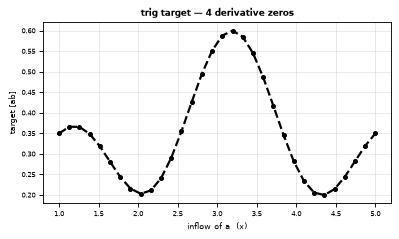

In [7]:
# ══════════════════════ KNOB B — the target ══════════════════════
TARGET_KIND   = "trig"
TARGET_KWARGS = dict(H=2, seed=500000042, amp=0.6, floor=0.2)

# Other families (uncomment one, and match the kwargs):
#   TARGET_KIND, TARGET_KWARGS = "gaussian", dict(center=3.0, width=0.7, amp=0.4)
#   TARGET_KIND, TARGET_KWARGS = "sigmoid",  dict(loc=3.0, sharpness=10.0, lo=0.02, hi=0.4)
#   TARGET_KIND, TARGET_KWARGS = "legendre", dict(degree=5, seed=3, amp=0.6, floor=0.2)
#   TARGET_KIND, TARGET_KWARGS = "tent",     dict(x0=3.0, w=2.0, amp=0.6)
#
# To sweep an ensemble at fixed complexity, vary only `seed`.
# To sweep complexity, vary `H` (trig) or `degree` (legendre).
# ═════════════════════════════════════════════════════════════════

target_vals = np.asarray(TARGETS[TARGET_KIND](u_vals, **TARGET_KWARGS), dtype=float)
target = jnp.asarray(target_vals)
n_deriv_zeros = count_derivative_zeros(target_vals, u_vals)

assert target_vals.shape == u_vals.shape
assert np.all(target_vals > 0), "targets are concentrations and must be positive"

print(f"target '{TARGET_KIND}' {TARGET_KWARGS}")
print(f"  range [{target_vals.min():.4f}, {target_vals.max():.4f}]   "
      f"mean {target_vals.mean():.4f}   derivative zeros {n_deriv_zeros}")

fig_t, ax_t = plt.subplots(figsize=(5, 3))
ax_t.plot(u_vals, target_vals, "k--o", lw=2, ms=3.5)
ax_t.set_xlabel(f"inflow of {INPUT_SPECIES}  (x)")
ax_t.set_ylabel(f"target [{READOUT_SPECIES}]")
ax_t.set_title(f"{TARGET_KIND} target — {n_deriv_zeros} derivative zeros")
ax_t.grid(True, alpha=0.3)
fig_t.tight_layout()
display(fig_t)
plt.close(fig_t)

## 4. Initialization and freezing

The freezing study is the reason this section exists. The three energetic classes enter the
kinetics differently, so asking *which* of them carries the learning capacity is a real
question — and the answer in the paper is that the thermodynamic drives $D_\alpha$ carry almost
all of it (60% success alone, against 8% for $\mu^\circ$ and 0% for $G^\ddagger$; 73% with all
three trainable). The flow rate $\gamma$ is frozen at $\log\gamma = 0$, i.e. $\gamma = 1$,
throughout that study.

The protocol is: **frozen classes are initialized to exactly zero and never updated; trainable
classes are initialized from $\mathcal N(0,\sigma)$ and trained.**

Freezing is implemented as nothing more than **multiplying the gradient by a 0/1 mask**. That
is exact rather than approximate, and it is worth understanding why: Adam's first and second
moments start at zero, and a masked gradient is *exactly* zero at every step, so the moments of
a frozen entry never become nonzero and its update is exactly $0/(\sqrt{0}+\epsilon) = 0$
forever. The parameter stays bit-identical. Note the flip side — this guarantee depends on the
gradient having been masked at *every* step, so unfreezing a class part-way through a run would
not behave like a fresh start.

> **Discrepancy worth knowing about.** The production runs used $\sigma = 0.6$, which is the
> script default and what actually produced the published Fig. 3 numbers. The paper's appendix
> text states $\theta_i \sim \mathcal N(0, 0.1)$. `INIT_SCALE` below defaults to **0.6** so this
> notebook reproduces the real runs; set it to 0.1 if you want the appendix as literally written.

In [8]:
# ═══════════ KNOB C — what trains, and from where ═══════════
TRAINABLE = {
    "dagger": False,   # G^dagger, transition-state energies   (R,)
    "mu":     False,   # mu^circ,  standard chemical potentials (N,)
    "drive":  True,    # D,        thermodynamic drives         (R,)
    "gamma":  False,   # log gamma, flow rate                   (1,)
}
INIT_SEED  = 42
INIT_SCALE = 0.6       # sigma of N(0, sigma) for trainable classes
# ════════════════════════════════════════════════════════════
#
# The seven freeze bins of Fig. 3 (gamma always frozen) are just the seven
# non-empty subsets of {dagger, mu, drive}. The default above is the
# "drive only" bin, which the paper finds is the strongest single class.

_shapes = {"dagger": (R,), "mu": (N,), "drive": (R,), "gamma": (1,)}
_keys = dict(zip(("dagger", "mu", "drive", "gamma"),
                 jax.random.split(jax.random.PRNGKey(INIT_SEED), 4)))

params, freeze_masks = {}, {}
for name, shape in _shapes.items():
    if TRAINABLE[name]:
        params[name] = jax.random.normal(_keys[name], shape) * INIT_SCALE
        freeze_masks[name] = jnp.ones(shape)
    else:
        params[name] = jnp.zeros(shape)      # frozen => identically zero
        freeze_masks[name] = jnp.zeros(shape)

n_train = sum(int(m.sum()) for m in freeze_masks.values())
print(f"{'class':8s} {'shape':>8s}  {'trainable':>10s}  init")
print("-" * 46)
for name, shape in _shapes.items():
    kind = f"N(0, {INIT_SCALE})" if TRAINABLE[name] else "zeros (frozen)"
    print(f"{name:8s} {str(shape):>8s}  {str(TRAINABLE[name]):>10s}  {kind}")
print("-" * 46)
print(f"{n_train} of {N + 2 * R + 1} parameters trainable")
print(f"gamma = {float(jnp.exp(params['gamma'])[0]):g}  "
      f"(log gamma = {float(params['gamma'][0]):g})")

class       shape   trainable  init
----------------------------------------------
dagger      (60,)       False  zeros (frozen)
mu          (39,)       False  zeros (frozen)
drive       (60,)        True  N(0, 0.6)
gamma        (1,)       False  zeros (frozen)
----------------------------------------------
60 of 160 parameters trainable
gamma = 1  (log gamma = 0)


## 5a. The residual

Collecting §1 into a single function: given a concentration vector $c$, the four parameter
arrays, and a reservoir row $r$,

$$k^+_\alpha = \exp\!\bigl(G^\ddagger_\alpha - \mu^\circ_{\mathrm L} - \mu^\circ_{\mathrm R} - \tfrac12 D_\alpha\bigr), \qquad
  k^-_\alpha = \exp\!\bigl(G^\ddagger_\alpha - \mu^\circ_{\mathrm P} + \tfrac12 D_\alpha\bigr),$$

$$F(c;\theta) \;=\; S\bigl(k^+ c_{\mathrm L} c_{\mathrm R} - k^- c_{\mathrm P}\bigr) \;+\; \gamma\,(r - c).$$

A **steady state is a root of $F$**. Note how the antisymmetry of $D_\alpha$ appears: it enters
the two directions with opposite sign, so it tilts the reaction, while $G^\ddagger_\alpha$ enters
both with the same sign and only scales the rate. The `li`/`ri`/`pi` index arrays turn the sums
over species into gathers.

`F_batch` is the same function vmapped across the grid, used only by the regularizers.

In [9]:
def make_residual(topo):
    """Return (F_single, F_batch) closing over this topology."""
    S = jnp.asarray(topo["S"])
    li = jnp.asarray(topo["li"], dtype=jnp.int32)
    ri = jnp.asarray(topo["ri"], dtype=jnp.int32)
    pi = jnp.asarray(topo["pi"], dtype=jnp.int32)

    def F_single(x, dagger, mu, drive, gamma, r):
        mu_prod = mu[pi]                  # mu of the product
        mu_reac = mu[li] + mu[ri]         # mu of the two reactants
        kf = jnp.exp(dagger - mu_reac - drive / 2.0)
        kr = jnp.exp(dagger - mu_prod + drive / 2.0)
        v_net = kf * x[li] * x[ri] - kr * x[pi]
        v_flow = jnp.exp(gamma) * (r - x)
        return S @ v_net + v_flow

    F_batch = jax.jit(jax.vmap(F_single, in_axes=(0, None, None, None, None, 0)))
    return F_single, F_batch


F_single, F_batch = make_residual(topo)

# sanity check: at theta = 0 with c = reservoir the flow term vanishes
_F0 = F_single(reservoir[0], jnp.zeros(R), jnp.zeros(N), jnp.zeros(R),
               jnp.zeros(1), reservoir[0])
print(f"F(reservoir; theta=0) -> shape {_F0.shape}, max|F| = {float(jnp.max(jnp.abs(_F0))):.4f}")

F(reservoir; theta=0) -> shape (39,), max|F| = 6.0000


## 5b. Steady states by pseudo-transient continuation

We need a root of $F$ at every grid point, every epoch. Plain Newton is a poor choice here: it
converges to *whatever* root is nearest, including unstable ones, and it is fragile far from a
solution. Instead we use **pseudo-transient continuation** (PTC) — implicit Euler on
$\dot c = F(c)$ with an adaptive pseudo-timestep:

$$\left(\frac{\delta_{ij}}{\Delta t_n} - \mathbb J_{ij}\right)\Delta c_j = F_i(c_n), \qquad
  c_{n+1} = \max(c_n + \Delta c,\; \epsilon_c),$$

where $\mathbb J = \partial F/\partial c$. As $\Delta t \to \infty$ this *is* Newton; at small
$\Delta t$ it is a damped time integration. So PTC begins by following the physical dynamics —
which means it is attracted to **dynamically stable** steady states, exactly the ones we want —
and sharpens into Newton as it closes in.

The step is adapted by **switched evolution relaxation** (SER): the pseudo-timestep tracks the
residual ratio, growing as $F$ shrinks and collapsing back to $\Delta t_0$ when it does not.

$$\Delta t_{n+1} = \max\!\Bigl(\Delta t_0,\; \min\bigl(\Delta t_0\,r_0/r_{n+1},\; g\,\Delta t_n,\; \Delta t_{\max}\bigr)\Bigr)$$

Convergence is on $\|F\|_\infty \le \varepsilon_{\mathrm{abs}} + \varepsilon_{\mathrm{rel}} r_0$.
Three details that matter:

- **The concentration floor** $\max(\cdot, \epsilon_c)$ keeps the iterate physical; a negative
  concentration would make the next mass-action flux meaningless.
- **A non-finite guard** reverts the step and resets $\Delta t$ to $\Delta t_0$ rather than
  letting a NaN propagate. A point that keeps tripping this simply exhausts its iteration
  budget and gets caught by the trust mask (§5c).
- **Warm starting.** Every epoch seeds from the previous epoch's steady states, so once training
  settles most points converge in a handful of iterations. Epoch 0 seeds from
  $\max(c^{\mathrm{ext}}, 10^{-6})$; a literal zero vector would make every mass-action flux
  vanish identically, which is a degenerate place to start.

The whole loop is a `lax.while_loop`, so it compiles to a single device kernel, and it is
`vmap`ped across the 32 grid points.

*(Two small deviations from the appendix text, kept because they are what ran: SER uses $L^2$
norms for the timestep ratio while convergence uses $L^\infty$; and the epoch-0 seed is the
floored reservoir rather than zeros.)*

In [10]:
def make_ptc_solver(F_single, cfg):
    """Single-point pseudo-transient continuation solver. Returns (x*, n_iter, |F|_inf)."""
    dt0, dt_max, g = cfg["ptc_dt0"], cfg["ptc_dt_max"], cfg["ptc_dt_growth"]
    maxiter, atol, rtol = cfg["ptc_maxiter"], cfg["ptc_atol"], cfg["ptc_rtol"]
    c_floor = cfg["c_floor"]

    def solve(dagger, mu, drive, gamma, r, x0):
        I = jnp.eye(x0.shape[0])
        F0 = F_single(x0, dagger, mu, drive, gamma, r)
        res0 = jnp.max(jnp.abs(F0))
        nrm0 = jnp.linalg.norm(F0) + 1e-30
        tol = atol + rtol * res0

        def cond_fn(state):
            _, res, i, _ = state
            return (res > tol) & (i < maxiter)

        def body_fn(state):
            x, _, i, dt = state
            Fv = F_single(x, dagger, mu, drive, gamma, r)
            J = jax.jacobian(lambda z: F_single(z, dagger, mu, drive, gamma, r))(x)

            delta = jnp.linalg.solve(I / dt - J, Fv)
            x_new = jnp.maximum(x + delta, c_floor)

            ok = jnp.all(jnp.isfinite(x_new))       # revert a blown-up step
            x_new = jnp.where(ok, x_new, x)

            F_new = F_single(x_new, dagger, mu, drive, gamma, r)
            res_new = jnp.max(jnp.abs(F_new))
            nrm_new = jnp.linalg.norm(F_new) + 1e-30

            dt_ser = dt0 * nrm0 / nrm_new           # SER
            dt_new = jnp.minimum(jnp.minimum(dt_ser, dt * g), dt_max)
            dt_new = jnp.maximum(dt_new, dt0)
            dt_new = jnp.where(ok, dt_new, dt0)
            return (x_new, res_new, i + 1, dt_new)

        x_f, res_f, n_it, _ = jax.lax.while_loop(
            cond_fn, body_fn, (x0, res0, 0, jnp.asarray(dt0)))
        return x_f, n_it, res_f

    return solve


ptc_solve = make_ptc_solver(F_single, CONFIG)

# vmap across grid points: parameters are shared, (reservoir row, seed) are batched
solve_grid = jax.jit(jax.vmap(ptc_solve, in_axes=(None, None, None, None, 0, 0)))

_x0 = jnp.maximum(reservoir, CONFIG["warm_start_floor"])
_xs, _it, _rs = solve_grid(params["dagger"], params["mu"], params["drive"],
                           params["gamma"], reservoir, _x0)
print(f"first solve: max iters {int(jnp.max(_it))}/{CONFIG['ptc_maxiter']}   "
      f"max |F| = {float(jnp.max(_rs)):.3e}   "
      f"converged {int(jnp.sum(_rs <= CONFIG['trust_tol']))}/{CONFIG['K']}")

first solve: max iters 19/150   max |F| = 4.664e-06   converged 22/32


## 5c. Gradients by implicit differentiation, and the regularizers

### Why not just backpropagate?

The steady state $c^*$ is defined *implicitly*, as the root of $F$. Differentiating through the
PTC iteration would mean storing and reversing 150 Newton-like steps per grid point per epoch —
expensive, memory-hungry, and numerically dominated by the transient path rather than the
answer. Worse, `lax.while_loop` is not reverse-mode differentiable at all.

Instead we use the **implicit function theorem**. Differentiating $F(c^*(\theta);\theta) = 0$:

$$\mathbb J \,\frac{\partial c^*}{\partial \theta_p} = -\frac{\partial F}{\partial \theta_p}
\qquad\Longrightarrow\qquad
\frac{\partial \mathcal L_{\mathrm{fit}}}{\partial \theta_p} = -\lambda^\top \frac{\partial F}{\partial \theta_p},
\qquad \lambda = \mathbb J^{-\mathsf T}\frac{\partial \mathcal L}{\partial c^*}.$$

So the cost is **one linear solve per grid point**, independent of how many iterations PTC took,
plus four cheap vector–Jacobian products for the four parameter classes. The gradient depends
only on the converged $c^*$, never on the path taken to reach it. Since the readout is a single
species, $\partial\mathcal L/\partial c^*$ is a one-hot vector.

> Do not "simplify" this into `jax.grad` of the solver. That is the one refactor that breaks it.

### The fit loss

$$\mathcal L_{\mathrm{fit}} = \sum_{k=1}^{K}\bigl(c^*_{\mathrm{readout},k} - f(x_k)\bigr)^2$$

*(This is a **sum** over grid points. The appendix writes $\tfrac1K\sum$; the code sums, and
since the regularizers below are means, that choice rescales the effective $\lambda$'s by a
factor $K$. The sum is what produced the published results, so it is what this notebook does.)*

### Three regularizers

Gradient descent could otherwise reduce the loss by drifting toward parameter regions where the
"steady state" the solver reports is not a trustworthy steady state at all. Each penalty closes
one such loophole, and each is evaluated with `stop_gradient` on $c^*$ — the gradient flows only
through $F$'s *explicit* $\theta$ dependence, which makes them nearly free and keeps them from
fighting the implicit-differentiation path.

| Penalty | Form | Closes the loophole |
|---|---|---|
| Residual, $\lambda = 10$ | $\bigl\langle \|F(c^*;\theta)\|^2 \bigr\rangle$ | $c^*$ must actually *be* a root |
| Spectral abscissa, $\lambda = 10^{-2}$ | $\bigl\langle \mathrm{ReLU}(\max_i \mathrm{Re}\,\lambda_i(\mathbb J) + \text{margin})^2 \bigr\rangle$ | the root must be dynamically **stable** |
| Log condition, $\lambda = 0.4$ | $\bigl\langle \mathrm{ReLU}(\chi - 9)^2 \bigr\rangle$, $\chi = \log_{10}\frac{\max_i|\lambda_i|}{\min_i|\lambda_i|}$ | the root must be **well conditioned**, so the adjoint solve is meaningful |

The stability penalty is what makes the eventual ODE verification in §7 pass: an unstable root
satisfies $F = 0$ but is never reached by the actual dynamics.

*(Two more code-vs-text notes. The condition number is computed from the ratio of eigenvalue
moduli, reusing the eigendecomposition already needed for the abscissa, whereas the appendix
writes it with singular values $\log_{10}(\sigma_{\max}/\sigma_{\min})$. And the abscissa uses
`eigvals` on the non-symmetric $\mathbb J$ directly, matching the appendix equation.)*

### The trust mask

A point whose PTC residual exceeds $\varepsilon_{\mathrm{trust}} = 10^{-6}$ did not really
converge, so its adjoint gradient is built on a linearization about a non-solution and is
meaningless. Those contributions are zeroed. **The mask applies only to the fit gradients** —
the penalty gradients are deliberately left unmasked, since pushing $\theta$ back toward a
solvable region is precisely what we want from a point that failed to converge. If more than
25% of the grid goes untrusted, the run aborts rather than reporting a fit to noise.

In [11]:
def make_loss_and_grads(F_single, F_batch, N, readout_idx, cfg):
    lam_res, lam_eig, lam_cond = cfg["lambda_res"], cfg["lambda_eig"], cfg["lambda_cond"]
    margin, chi = cfg["spectral_margin"], cfg["chi_thresh"]

    def _jac(x, dagger, mu, drive, gamma, r):
        return jax.jacobian(lambda z: F_single(z, dagger, mu, drive, gamma, r))(x)

    # ── fit term: implicit differentiation, one adjoint solve per grid point ──
    def lag_single(x_star, dagger, mu, drive, gamma, r, target_val):
        pred = x_star[readout_idx]
        loss = (pred - target_val) ** 2

        dLdx = jnp.zeros(N).at[readout_idx].set(2.0 * (pred - target_val))
        lam = jnp.linalg.solve(_jac(x_star, dagger, mu, drive, gamma, r).T, dLdx)

        _, vjp_d = jax.vjp(lambda p: F_single(x_star, p, mu, drive, gamma, r), dagger)
        _, vjp_m = jax.vjp(lambda p: F_single(x_star, dagger, p, drive, gamma, r), mu)
        _, vjp_r = jax.vjp(lambda p: F_single(x_star, dagger, mu, p, gamma, r), drive)
        _, vjp_g = jax.vjp(lambda p: F_single(x_star, dagger, mu, drive, p, r), gamma)

        return (loss, -vjp_d(lam)[0], -vjp_m(lam)[0],
                -vjp_r(lam)[0], -vjp_g(lam)[0], pred)

    lag_batch = jax.vmap(lag_single, in_axes=(0, None, None, None, None, 0, 0))

    # ── regularizers: x* frozen, gradient only through F's explicit theta ──
    def _residual_penalty(dagger, mu, drive, gamma, X, Rb):
        F = F_batch(jax.lax.stop_gradient(X), dagger, mu, drive, gamma, Rb)
        return jnp.mean(jnp.sum(F * F, axis=-1))

    def _jac_scores(x_star, dagger, mu, drive, gamma, r):
        eigs = jnp.linalg.eigvals(_jac(x_star, dagger, mu, drive, gamma, r))
        abs_e = jnp.abs(eigs)
        log_cond = (jnp.log10(jnp.maximum(jnp.max(abs_e), 1e-30))
                    - jnp.log10(jnp.maximum(jnp.min(abs_e), 1e-30)))
        return jnp.max(jnp.real(eigs)), log_cond

    def _jac_penalty(dagger, mu, drive, gamma, X, Rb):
        spec, log_cond = jax.vmap(
            _jac_scores, in_axes=(0, None, None, None, None, 0)
        )(jax.lax.stop_gradient(X), dagger, mu, drive, gamma, Rb)
        L_eig = jnp.mean(jax.nn.relu(spec + margin) ** 2)
        L_cond = jnp.mean(jax.nn.relu(log_cond - chi) ** 2)
        return lam_eig * L_eig + lam_cond * L_cond, (L_eig, L_cond)

    @jax.jit
    def loss_and_grads(X, dagger, mu, drive, gamma, Rb, target_vals, trust_mask):
        losses, gd, gm, gr, gg, preds = lag_batch(
            X, dagger, mu, drive, gamma, Rb, target_vals)

        # fit: SUM over grid points; the trust mask gates ONLY the fit gradients
        m = trust_mask.astype(losses.dtype)[:, None]
        total = jnp.sum(losses)
        gd = jnp.sum(gd * m, axis=0)
        gm = jnp.sum(gm * m, axis=0)
        gr = jnp.sum(gr * m, axis=0)
        gg = jnp.sum(gg * m, axis=0)

        L_res, (pd, pm, pr, pg) = jax.value_and_grad(
            _residual_penalty, argnums=(0, 1, 2, 3)
        )(dagger, mu, drive, gamma, X, Rb)
        total = total + lam_res * L_res
        gd, gm = gd + lam_res * pd, gm + lam_res * pm
        gr, gg = gr + lam_res * pr, gg + lam_res * pg

        (L_jac, (L_eig, L_cond)), (qd, qm, qr, qg) = jax.value_and_grad(
            _jac_penalty, argnums=(0, 1, 2, 3), has_aux=True
        )(dagger, mu, drive, gamma, X, Rb)
        total = total + L_jac        # already weighted inside _jac_penalty
        gd, gm, gr, gg = gd + qd, gm + qm, gr + qr, gg + qg

        grads = {"dagger": gd, "mu": gm, "drive": gr, "gamma": gg}
        return total, grads, preds, losses, L_res, L_eig, L_cond

    return loss_and_grads


loss_and_grads = make_loss_and_grads(F_single, F_batch, N, readout_idx, CONFIG)

_tm = _rs <= CONFIG["trust_tol"]
_l, _g, _p, _pl, _lr, _le, _lc = loss_and_grads(
    _xs, params["dagger"], params["mu"], params["drive"], params["gamma"],
    reservoir, target, _tm)
print(f"loss {float(_l):.4f}  |  L_res {float(_lr):.3e}  "
      f"L_eig {float(_le):.3e}  L_cond {float(_lc):.3e}")
print("gradient norms:", {k: round(float(jnp.linalg.norm(v)), 4) for k, v in _g.items()})

loss 2.5514  |  L_res 3.110e-12  L_eig 0.000e+00  L_cond 0.000e+00
gradient norms: {'dagger': 0.3209, 'drive': 0.4704, 'gamma': 0.1222, 'mu': 0.7384}


## 5d. Updates and stopping

**Per-class gradient clipping.** Each of the four classes is clipped to $\|g\|_2 \le 10$
*separately*. This matters because the classes have very different sizes and sensitivities —
$\gamma$ is one number while `mu` has $N$ — and a single global clip would let whichever class
happens to have the largest gradient throttle all the others.

**Order of operations: clip, then mask, then Adam.** The clip factor is computed from the
*unmasked* norms, and the reported gradient norms are likewise pre-clip and pre-mask, so the
dashboard shows the true gradient signal rather than the post-processed one.

**Adam** is hand-rolled — four independent moment pairs, one per class, with the bias-correction
step counter $t$ being the global epoch (+1). It is written out rather than pulled from Optax so
that the freezing argument in §4 is verifiable by reading this cell.

**Stopping.** Four ways a run ends: the epoch budget (16000); a stationary point
($\sum_c\|g_c\| < 2\times10^{-4}$); a loss plateau (relative change $< 10^{-6}$ over 500 epochs);
or solver collapse (more than 25% of the grid untrusted). The first three are recorded as normal
terminations; the last is a failure.

`point_diagnostics` computes $\mathrm{cond}(\mathbb J)$ and the spectral abscissa at every grid
point for the dashboard. It is deliberately *not* called every epoch — that would be 32 dense
$N\times N$ eigendecompositions per step — only on refresh epochs.

In [12]:
def adam_update(param, grad, m, v, t, lr, b1, b2, eps):
    """Adam. Frozen entries receive grad == 0 exactly, so m, v stay 0 and param never moves."""
    m = b1 * m + (1 - b1) * grad
    v = b2 * v + (1 - b2) * grad ** 2
    mhat = m / (1 - b1 ** t)
    vhat = v / (1 - b2 ** t)
    return param - lr * mhat / (jnp.sqrt(vhat) + eps), m, v


def clip_norm(g, gnorm, gmax):
    """Per-class L2 clip, using the unmasked norm."""
    return g * (gmax / gnorm) if gnorm > gmax else g


@jax.jit
def point_diagnostics(X, dagger, mu, drive, gamma, Rb):
    """cond(J) and spectral abscissa at every grid point. Dashboard epochs only."""
    def one(x, r):
        eigs = jnp.linalg.eigvals(
            jax.jacobian(lambda z: F_single(z, dagger, mu, drive, gamma, r))(x))
        a = jnp.abs(eigs)
        return jnp.max(a) / jnp.maximum(jnp.min(a), 1e-30), jnp.max(jnp.real(eigs))

    return jax.vmap(one, in_axes=(0, 0))(X, Rb)

## 6. The dashboard

Eleven panels, refreshed every `plot_every` epochs (25 by default — production wrote a PNG only
every 400, which is too coarse to watch). A full repaint costs 0.2–0.5 s, so at 25 it adds a
couple of percent to the epoch budget; raise it if you would rather have the throughput. The
parameter traces keep $P$ floats per sampled epoch (~20 MB for the default 16000 epochs $\times$
160 parameters) — raise `param_every` for much larger networks.
Each panel exists to catch a specific failure mode:

| Panel | Reads |
|---|---|
| Training Loss | The fit loss (log scale) with $\lambda\!\cdot\!L_{\mathrm{res}}$ on the twin axis. If the red curve climbs while the dark one falls, the optimizer is buying fit by degrading the steady states. |
| Last & Best Fit | Current and best-ever response against the target, annotated with $\max|r|$. |
| Response Evolution | Snapshots at log-spaced epochs, dark to bright. Shows *how* the curve is being built. |
| Normalized Gradient Norms | Each class's share of the total gradient. This is the panel the freezing study is about — it shows which energetic class is doing the work. |
| Solver Cost & Trust | PTC iterations per epoch and the number of trusted points. A cost spike or a trust dip is an early warning of solver trouble. |
| Per-Point Convergence | Per-point loss bars (red = solver suspect) with the residual overlaid. Localizes trouble to specific inflow values. |
| Solver Stiffness | $\mathrm{cond}(\mathbb J)$ and the spectral abscissa per point. Approaching $10^9$, or an abscissa crossing zero, means the regularizers are about to earn their keep. |
| gamma | The trace of $\log\gamma$. Flat at 0 whenever $\gamma$ is frozen. |
| dagger / mu / drive | Parameter evolution heatmaps: one row per parameter, **epoch on $x$**, rows sorted by variance so the movers surface at the top. Sampled every `param_every` epochs (1 by default), so the $x$ axis is as fine as the loss curve's and the two can be read against each other. A frozen class is one flat colour and titled `[FROZEN]` — a visual check that freezing worked. |

### How the live refresh works

One `Figure` is created once, outside the loop, and its four twin axes are created with it. The
refresh clears the axes and repaints, then swaps the payload of a **single output slot** via a
display handle.

```python
FIG, AX, TW = make_dashboard()
DASH = display(FIG, display_id="crn_dashboard")
...
DASH.update(FIG)     # replaces the image in place
```

This is preferable to `clear_output(wait=True)`, which tears down and rebuilds the whole output
area — and which would also wipe the text log printed from the same cell. With a display handle,
the dashboard stays pinned while the log scrolls beneath it.

Two things here prevent a slow leak over thousands of epochs. Calling `twinx()` inside the
refresh is the classic mistake: it appends a *new* `Axes` to the figure every single time, so
`len(fig.axes)` grows without bound and rendering gets monotonically slower. And creating a new
`Figure` per refresh would grow pyplot's registry until it warns. Here exactly one figure and
exactly four twins exist for the entire run; `ax.clear()` drops the artists each pass. The
tradeoff of `clear()` is that it also resets scales, labels and limits, so the refresh re-applies
them every time.

In [13]:
def make_dashboard():
    """One persistent figure. Twin axes are created HERE and never again."""
    fig = plt.figure(figsize=(15.0, 10.5))
    gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.42)
    AX = {(i, j): fig.add_subplot(gs[i, j]) for i in range(3) for j in range(4)}
    TW = {k: AX[k].twinx() for k in [(0, 0), (1, 0), (1, 1), (1, 2)]}
    AX[2, 3].axis("off")                      # deliberately empty, as in production
    return fig, AX, TW


def fresh_history():
    return {
        "loss": [], "l_res": [], "l_eig": [], "l_cond": [],
        "gn_epoch": [], "gn_dagger": [], "gn_mu": [], "gn_drive": [], "gn_gamma": [],
        "ss_epoch": [], "ss_total_iters": [], "ss_max_iters": [], "ss_n_trusted": [],
        "ph_epoch": [], "ph_gamma": [], "ph_dagger": [], "ph_mu": [], "ph_drive": [],
        "curves": [], "preds": None, "best_preds": None, "best_epoch": 0,
        "point_res": None, "point_loss": None, "point_cond": None, "point_abscissa": None,
    }


FIG, AX, TW = make_dashboard()
DASH = None    # created on the first refresh, then reused

In [14]:
def redraw(epoch, H):
    """Repaint all 11 panels from the history dict and swap the output payload."""
    global DASH
    for a in list(AX.values()) + list(TW.values()):
        a.clear()
    for a in TW.values():
        # clear() resets the label back to the left spine; twins must re-assert it
        a.yaxis.set_label_position("right")
        a.yaxis.tick_right()
    AX[2, 3].axis("off")
    K = len(u_vals)

    # ── [0,0] loss (+ lambda * L_res on the twin) ─────────────────────────────
    ax, axr = AX[0, 0], TW[0, 0]
    if H["loss"]:
        ax.semilogy(H["loss"], color="#2c3e50", lw=1.5)
    ax.set(xlabel="Epoch", title="Training Loss")
    ax.set_ylabel("Loss (SSE)", color="#2c3e50")
    ax.tick_params(axis="y", labelcolor="#2c3e50")
    ax.grid(True, alpha=0.3)
    scaled = np.asarray(H["l_res"], dtype=float) * CONFIG["lambda_res"]
    scaled = np.where(scaled > 0, scaled, np.nan)          # avoid log(0)
    if scaled.size and np.any(np.isfinite(scaled)):
        axr.semilogy(scaled, color="#c0392b", lw=1.2, ls="--")
        axr.set_ylabel(r"$\lambda\cdot\langle\|F\|^2\rangle$", color="#c0392b")
        axr.tick_params(axis="y", labelcolor="#c0392b")
    axr.grid(False)

    # ── [0,1] last & best fit ─────────────────────────────────────────────────
    ax = AX[0, 1]
    ax.plot(u_vals, target_vals, "k--", lw=2.2, label="Target")
    if H["best_preds"] is not None:
        rb = np.abs(H["best_preds"] - target_vals).max()
        ax.plot(u_vals, H["best_preds"], "D-", color="#2980b9", ms=3, lw=1.5,
                label=f"Best (ep {H['best_epoch']}, max|r|={rb:.4f})")
    if H["preds"] is not None:
        rl = np.abs(H["preds"] - target_vals).max()
        ax.plot(u_vals, H["preds"], "s-", color="#e74c3c", ms=3, lw=1.3,
                label=f"Last (max|r|={rl:.4f})")
        ax.fill_between(u_vals, target_vals, H["preds"], alpha=0.12, color="#e74c3c")
        ax.set_title(f"Last & Best Fit  (max|r|={rl:.4f})")
    else:
        ax.set_title("Last & Best Fit")
    ax.set(xlabel=f"Inflow of {INPUT_SPECIES}", ylabel=f"[{READOUT_SPECIES}] at steady state")
    ax.legend(); ax.grid(True, alpha=0.3)

    # ── [0,2] response evolution ──────────────────────────────────────────────
    ax = AX[0, 2]
    ax.plot(u_vals, target_vals, "k--", lw=2.2, label="Target", zorder=10)
    nc = len(H["curves"])
    for i, (ep, curve) in enumerate(H["curves"]):
        ax.plot(u_vals, curve, "-o", ms=2, lw=1.1, alpha=0.85,
                color=plt.cm.plasma(i / max(nc - 1, 1)), label=f"Ep {ep}")
    ax.set(xlabel=f"Inflow of {INPUT_SPECIES}", ylabel=f"[{READOUT_SPECIES}]",
           title="Response Evolution")
    ax.legend(fontsize=5, ncol=2); ax.grid(True, alpha=0.3)

    # ── [0,3] normalized per-class gradient norms ─────────────────────────────
    ax = AX[0, 3]
    if H["gn_epoch"]:
        tot = np.maximum(sum(np.asarray(H[f"gn_{c}"], dtype=float)
                             for c in ("dagger", "mu", "drive", "gamma")), 1e-30)
        for c, col in [("dagger", "#e74c3c"), ("mu", "#2980b9"),
                       ("drive", "#27ae60"), ("gamma", "#f39c12")]:
            ax.plot(H["gn_epoch"], np.asarray(H[f"gn_{c}"], dtype=float) / tot,
                    label=c, color=col, lw=1.2)
        ax.legend()
    ax.set(xlabel="Epoch", ylabel="Relative gradient fraction", ylim=(-0.05, 1.05),
           title="Normalized Gradient Norms")
    ax.grid(True, alpha=0.3)

    # ── [1,0] solver cost & trust ─────────────────────────────────────────────
    ax, axt = AX[1, 0], TW[1, 0]
    if H["ss_epoch"]:
        ax.plot(H["ss_epoch"], H["ss_total_iters"], color="#2980b9", lw=1.4,
                label="Total PTC iters")
        ax.plot(H["ss_epoch"], H["ss_max_iters"], color="#e67e22", lw=1.4,
                label="Max per point")
        ax.axhline(K, color="gray", ls=":", alpha=0.5, label=f"{K} pts x 1 iter")
        axt.plot(H["ss_epoch"], H["ss_n_trusted"], color="#27ae60", lw=1.4, alpha=0.75,
                 label="Trusted pts")
        axt.axhline(K, color="#27ae60", ls="--", alpha=0.3)
        axt.set_ylim(-0.5, K + 1)
        axt.set_ylabel("Trusted points", color="#27ae60")
        axt.tick_params(axis="y", labelcolor="#27ae60")
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = axt.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc="upper right")
    ax.set(xlabel="Epoch", ylabel="PTC iterations", title="Solver Cost & Trust per Epoch")
    ax.grid(True, alpha=0.3); axt.grid(False)

    # ── [1,1] per-point convergence ───────────────────────────────────────────
    ax, ax2 = AX[1, 1], TW[1, 1]
    if H["point_loss"] is not None:
        ok = np.asarray(H["point_res"]) < CONFIG["trust_tol"]
        width = (u_vals[-1] - u_vals[0]) / K * 0.4
        bars = ax.bar(u_vals, np.maximum(H["point_loss"], 1e-16), width=width,
                      color="#3498db", alpha=0.7, label="Per-point loss", zorder=3)
        for b, good in zip(bars, ok):
            if not good:
                b.set_color("#e74c3c"); b.set_alpha(0.9)
        ax.set_yscale("log")                      # ax.clear() dropped this; re-apply
        ax.set_ylabel("Per-point loss", color="#3498db")
        ax.tick_params(axis="y", labelcolor="#3498db")

        ax2.semilogy(u_vals, np.maximum(H["point_res"], 1e-30), "D-", color="#2ecc71",
                     ms=3, lw=1.3, label=r"$\|F(c^*)\|_\infty$", zorder=5)
        ax2.axhline(CONFIG["trust_tol"], color="#2ecc71", ls="--", alpha=0.5, lw=1)
        ax2.set_ylabel("Solver residual", color="#2ecc71")
        ax2.tick_params(axis="y", labelcolor="#2ecc71")
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        extra = ["solver suspect (red)"] if (~ok).any() else []
        ax.legend(h1 + h2, l1 + l2 + extra, loc="upper right")
    ax.set(xlabel=f"Inflow of {INPUT_SPECIES}", title="Per-Point Convergence Diagnostic")
    ax.grid(True, alpha=0.2); ax2.grid(False)

    # ── [1,2] solver stiffness ────────────────────────────────────────────────
    ax, ax2 = AX[1, 2], TW[1, 2]
    if H["point_cond"] is not None:
        ax.semilogy(u_vals, np.maximum(H["point_cond"], 1e-30), "o-", color="#8e44ad",
                    ms=4, lw=1.2, label="cond(J)")
        ax.axhline(10 ** CONFIG["chi_thresh"], color="#8e44ad", ls="--", alpha=0.5, lw=1)
        ax.set_ylabel("Condition number", color="#8e44ad")
        ax.tick_params(axis="y", labelcolor="#8e44ad")

        ax2.plot(u_vals, H["point_abscissa"], "s-", color="#f39c12", ms=3, lw=1.1,
                 alpha=0.8, label=r"max Re $\lambda(J)$")
        ax2.axhline(0.0, color="#f39c12", ls=":", alpha=0.6, lw=1)
        ax2.set_ylabel("Spectral abscissa", color="#f39c12")
        ax2.tick_params(axis="y", labelcolor="#f39c12")
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc="upper right")
    ax.set(xlabel=f"Inflow of {INPUT_SPECIES}", title="Solver Stiffness per Point")
    ax.grid(True, alpha=0.3); ax2.grid(False)

    # ── [1,3] gamma trace ─────────────────────────────────────────────────────
    ax = AX[1, 3]
    if H["ph_epoch"]:
        ax.plot(H["ph_epoch"], H["ph_gamma"], "-o", color="#16a085", lw=1.6, ms=2)
    ax.set(xlabel="Epoch", ylabel=r"$\log\gamma$", title=r"$\gamma$ (dilution rate)")
    ax.grid(True, alpha=0.3)

    # ── [2,0..2] parameter heatmaps ───────────────────────────────────────────
    for col, (pname, labels, n_p) in enumerate([
            ("dagger", topo["reaction_labels"], R),
            ("mu", topo["species"], N),
            ("drive", topo["reaction_labels"], R)]):
        ax = AX[2, col]
        if len(H["ph_epoch"]) >= 2:
            mat = np.asarray(H[f"ph_{pname}"])                    # (snapshots, n_params)
            order = np.argsort(-np.std(mat, axis=0))              # movers first
            sorted_mat = mat[:, order].T
            vabs = max(np.max(np.abs(sorted_mat)), 1e-6)
            # extent puts real epoch numbers on x instead of the snapshot index,
            # so this panel reads against the loss curve. Half-step padding keeps
            # pixel centres on their epochs.
            eps = H["ph_epoch"]
            half = 0.5 * CONFIG["param_every"]
            ax.imshow(sorted_mat, aspect="auto", cmap="coolwarm",
                      interpolation="nearest", vmin=-vabs, vmax=vabs,
                      extent=(eps[0] - half, eps[-1] + half, n_p, 0))
            # tick a readable subset spread over ALL rows -- ticking rows 0..k
            # would crowd every label into the top of the axis
            ticks = np.unique(np.linspace(0, n_p - 1, min(n_p, 16)).astype(int))
            ax.set_yticks(ticks + 0.5)                # row i spans [i, i+1] in y
            ax.set_yticklabels([labels[order[i]][:12] for i in ticks], fontsize=5)
            frozen = "  [FROZEN]" if not TRAINABLE[pname] else ""
            ax.set_title(f"{pname} evolution{frozen}")
        else:
            ax.set_title(f"{pname} evolution")
        ax.set(xlabel="Epoch", ylabel=f"{pname} (sorted by std)")
        ax.grid(False)

    trained = ", ".join(k for k, v in TRAINABLE.items() if v) or "nothing"
    FIG.suptitle(
        f"{topo['name']} -- [{READOUT_SPECIES}] vs inflow({INPUT_SPECIES}) -- "
        f"target: {TARGET_KIND}, {n_deriv_zeros} deriv zeros -- "
        f"{N} species, {R} rxns, delta={delta} -- trainable: {trained} -- epoch {epoch}",
        fontsize=11, fontweight="bold", y=0.995)

    if DASH is None:
        DASH = display(FIG, display_id="crn_dashboard")
    else:
        DASH.update(FIG)

## 6b. The training loop

Before the loop there is one **warm-up solve**. Its obvious job is to trigger XLA compilation
outside the timed loop, but it has a second, load-bearing effect: its result becomes the epoch-0
warm-start cache. So epoch 0 begins from an already-relaxed state, and any grid point that
exhausted its 150-iteration budget during the warm-up gets a fresh budget at epoch 0. This is
what production did, and skipping it can make epoch 0 trip the 25% trust threshold and abort
immediately.

Then each epoch, in order:

1. **Solve** all $K$ steady states with PTC, warm-started from last epoch's roots, and cache
   the new roots as next epoch's warm start.
2. **Trust**: mark points with $\|F\|_\infty \le 10^{-6}$; abort if more than 25% failed.
3. **Loss and gradients**: one JIT call for the fit adjoints plus all three regularizers.
4. **Diagnostics** for the dashboard ($\mathrm{cond}\,\mathbb J$, spectral abscissa per point),
   on dashboard epochs only and *before* the update, so they belong to the same $\theta$ that
   produced these roots.
5. **Norms** per class, recorded before any clipping or masking.
6. **Stopping checks**: stationary point, then plateau.
7. **Clip** each class to $\|g\|_2 \le 10$, **mask** the frozen classes, **Adam**.
8. On cadence: append history, refresh the dashboard, print a log row.

The dashboard appears below and updates in place; the text log accumulates underneath it.

solver compiled, warm-start cache primed in 0.0s (22/32 already trusted)


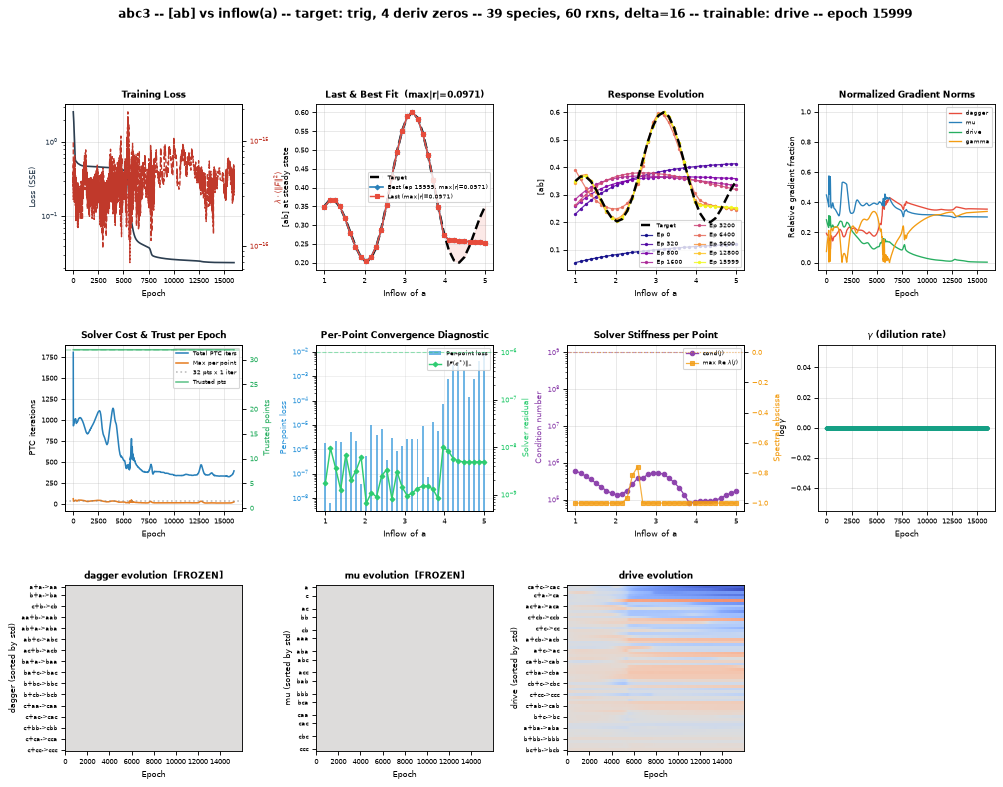

  epoch     0 | loss 2.551373e+00 | best 2.551373e+00 | |grad| 2.54e+00 | trusted 32/32 | max|F| 9.99e-09 | PTC max  63 |    3.0s
  epoch    50 | loss 1.912568e+00 | best 1.912568e+00 | |grad| 2.95e+00 | trusted 32/32 | max|F| 1.08e-08 | PTC max  35 |   14.6s
  epoch   100 | loss 1.284130e+00 | best 1.284130e+00 | |grad| 2.86e+00 | trusted 32/32 | max|F| 1.11e-08 | PTC max  38 |   26.3s
  epoch   150 | loss 8.094306e-01 | best 8.094306e-01 | |grad| 2.09e+00 | trusted 32/32 | max|F| 9.42e-09 | PTC max  41 |   38.3s
  epoch   200 | loss 5.853894e-01 | best 5.853894e-01 | |grad| 8.99e-01 | trusted 32/32 | max|F| 9.84e-09 | PTC max  43 |   50.5s
  epoch   250 | loss 5.468595e-01 | best 5.468440e-01 | |grad| 1.73e-01 | trusted 32/32 | max|F| 9.10e-09 | PTC max  46 |   63.4s
  epoch   300 | loss 5.477787e-01 | best 5.468440e-01 | |grad| 4.72e-01 | trusted 32/32 | max|F| 9.73e-09 | PTC max  42 |   76.5s
  epoch   350 | loss 5.347214e-01 | best 5.347214e-01 | |grad| 3.21e-01 | trusted 32/32 | 

In [15]:
prm = dict(params)                                        # working copy
opt_m = {k: jnp.zeros(v.shape) for k, v in prm.items()}
opt_v = {k: jnp.zeros(v.shape) for k, v in prm.items()}

# ── warm-up solve: compiles the solver AND primes the warm-start cache ───────
# This mirrors production, where the compile-triggering solve's result *becomes*
# the epoch-0 seed. It is not cosmetic: a point that exhausts its 150-iteration
# budget on this first pass gets a fresh budget at epoch 0, and that is often
# what keeps epoch 0 inside the 25% trust threshold instead of aborting.
_t0 = time.time()
ss_cache, _, _res0 = solve_grid(
    prm["dagger"], prm["mu"], prm["drive"], prm["gamma"], reservoir,
    jnp.maximum(reservoir, CONFIG["warm_start_floor"]))
ss_cache.block_until_ready()
print(f"solver compiled, warm-start cache primed in {time.time() - _t0:.1f}s")

E = CONFIG["max_epoch"]
H = fresh_history()

# response snapshots at log-spaced fractions of the run
snapshot_epochs = sorted({max(0, min(E - 1, int(f * E)))
                          for f in (0.0, 0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0)})

best_loss = np.inf
exit_reason = "max_epoch"
t_start = time.time()

for epoch in range(E):
    last = (epoch == E - 1)
    do_plot = (epoch % CONFIG["plot_every"] == 0) or last

    # 1 ── steady states, warm-started from last epoch's roots -----------------
    x_stars, iters, point_res = solve_grid(
        prm["dagger"], prm["mu"], prm["drive"], prm["gamma"], reservoir, ss_cache)
    ss_cache = x_stars

    # 2 ── trust ---------------------------------------------------------------
    trust_mask = point_res <= CONFIG["trust_tol"]
    n_trusted = int(jnp.sum(trust_mask))

    # 3 ── loss and gradients --------------------------------------------------
    loss, grads, preds, pt_losses, l_res, l_eig, l_cond = loss_and_grads(
        x_stars, prm["dagger"], prm["mu"], prm["drive"], prm["gamma"],
        reservoir, target, trust_mask)
    loss = float(loss)

    H["loss"].append(loss)
    H["l_res"].append(float(l_res))
    H["l_eig"].append(float(l_eig))
    H["l_cond"].append(float(l_cond))

    if CONFIG["K"] - n_trusted > CONFIG["unstable_frac"] * CONFIG["K"]:
        exit_reason = "solver_unstable"
        print(f"  epoch {epoch:5d} | {CONFIG['K'] - n_trusted}/{CONFIG['K']} untrusted "
              f"-> solver unstable, stopping")
        break

    # parameter traces, sampled here (pre-update) so that snapshot i is exactly
    # the theta that produced H["loss"][i] -- that alignment is what lets the
    # heatmaps below share the loss curve's epoch axis.
    if epoch % CONFIG["param_every"] == 0 or last:
        H["ph_epoch"].append(epoch)
        H["ph_gamma"].append(float(prm["gamma"][0]))
        for k in ("dagger", "mu", "drive"):
            H[f"ph_{k}"].append(np.asarray(prm[k]))

    preds_np = np.asarray(preds)
    H["preds"] = preds_np
    if epoch in snapshot_epochs:
        H["curves"].append((epoch, preds_np.copy()))
    if loss < best_loss:
        best_loss, H["best_preds"], H["best_epoch"] = loss, preds_np.copy(), epoch

    # 4 ── per-point diagnostics for the dashboard ----------------------------
    # Taken HERE, at the same parameters that produced x_stars -- the Adam
    # update below would otherwise pair this epoch's roots with next epoch's
    # parameters. Expensive (K dense eigendecompositions), so dashboard only.
    if do_plot:
        cond_k, absc_k = point_diagnostics(
            x_stars, prm["dagger"], prm["mu"], prm["drive"], prm["gamma"], reservoir)
        H["point_res"] = np.asarray(point_res)
        H["point_loss"] = np.asarray(pt_losses)
        H["point_cond"] = np.asarray(cond_k)
        H["point_abscissa"] = np.asarray(absc_k)

    # 5 ── gradient norms (pre-clip, pre-mask) --------------------------------
    gnorms = {k: float(jnp.linalg.norm(g)) for k, g in grads.items()}
    total_gnorm = sum(gnorms.values())

    # 6 ── stopping ------------------------------------------------------------
    if total_gnorm < CONFIG["gnorm_tol"]:
        exit_reason = "grad_norm"
        print(f"  epoch {epoch:5d} | |grad| = {total_gnorm:.2e} -> stationary, stopping")
        break
    W = CONFIG["plateau_window"]
    if len(H["loss"]) >= W:
        old = H["loss"][-W]
        if old > 0 and abs(old - loss) / old < CONFIG["plateau_tol"]:
            exit_reason = "loss_plateau"
            print(f"  epoch {epoch:5d} | rel change < {CONFIG['plateau_tol']:.0e} "
                  f"over {W} epochs -> plateau, stopping")
            break

    # 7 ── clip -> mask -> Adam ------------------------------------------------
    for k in prm:
        g = clip_norm(grads[k], gnorms[k], CONFIG["grad_clip"])
        g = g * freeze_masks[k]                           # freezing, exactly
        prm[k], opt_m[k], opt_v[k] = adam_update(
            prm[k], g, opt_m[k], opt_v[k], epoch + 1,
            CONFIG["lr"], CONFIG["beta1"], CONFIG["beta2"], CONFIG["adam_eps"])

    # 8 ── history / dashboard / log ------------------------------------------
    if epoch % CONFIG["log_every"] == 0 or last:
        H["gn_epoch"].append(epoch)
        for k, v in gnorms.items():
            H[f"gn_{k}"].append(v)
        H["ss_epoch"].append(epoch)
        H["ss_total_iters"].append(int(jnp.sum(iters)))
        H["ss_max_iters"].append(int(jnp.max(iters)))
        H["ss_n_trusted"].append(n_trusted)

    if do_plot:
        redraw(epoch, H)

    if epoch % CONFIG["print_every"] == 0 or last:
        print(f"  epoch {epoch:5d} | loss {loss:.6e} | best {best_loss:.6e} "
              f"| |grad| {total_gnorm:.2e} | trusted {n_trusted}/{CONFIG['K']} "
              f"| max|F| {float(jnp.max(point_res)):.2e} "
              f"| PTC max {int(jnp.max(iters)):3d} | {time.time() - t_start:6.1f}s")

# final refresh so the picture always matches the end of the run. If the last
# epoch was already a dashboard epoch this is a no-op; otherwise we finish the
# panels here. Note every `break` above happens *before* the Adam update, so
# `prm` still matches `x_stars` at this point either way.
if not do_plot:                      # this epoch skipped step 4, so fill it in now
    cond_k, absc_k = point_diagnostics(
        x_stars, prm["dagger"], prm["mu"], prm["drive"], prm["gamma"], reservoir)
    H["point_res"] = np.asarray(point_res)
    H["point_loss"] = np.asarray(pt_losses)
    H["point_cond"] = np.asarray(cond_k)
    H["point_abscissa"] = np.asarray(absc_k)
if not H["ph_epoch"] or H["ph_epoch"][-1] != epoch:
    H["ph_epoch"].append(epoch)
    H["ph_gamma"].append(float(prm["gamma"][0]))
    for k in ("dagger", "mu", "drive"):
        H[f"ph_{k}"].append(np.asarray(prm[k]))
redraw(epoch, H)

print()
print(f"exit reason : {exit_reason}")
print(f"epochs run  : {epoch + 1} of {E}")
print(f"best loss   : {best_loss:.6e}  (epoch {H['best_epoch']})")
print(f"wall time   : {time.time() - t_start:.1f}s")
print(f"gamma       : {float(jnp.exp(prm['gamma'])[0]):.6f}")
for k in ("dagger", "mu", "drive"):
    moved = float(jnp.max(jnp.abs(prm[k])))
    tag = "" if TRAINABLE[k] else "   <- frozen, must be exactly 0"
    print(f"max |{k:6s}|: {moved:.6e}{tag}")

## 7. Quasistatic ODE verification

A low loss is **not** sufficient. The root finder can land on a mathematically valid steady state
that the physical dynamics would never reach — an unstable root, or one in a basin the system
never enters. Since the claim is about what a *chemical system* can compute, the trained network
has to be checked against the actual dynamics.

So we throw away the root finder and integrate

$$\dot c = F(c;\theta)$$

with a stiff implicit solver (Kvaerno5, PID-controlled at $10^{-6}$) out to $t_1 = 5\times10^6$ —
far beyond any relaxation timescale in the system — and read off the readout concentration.

The sweep is **quasistatic**: point $k+1$ starts from the converged state of point $k$, mimicking
an experiment where the input is ramped slowly and the system tracks its steady-state branch.
This is a strictly harder test than integrating each point from its own root, because it will
expose hysteresis or a branch that the system falls off. If a point fails to converge we fall
back to that point's root-finder solution rather than propagating a bad state, so one failure
does not poison the rest of the sweep.

**Success requires all three:**

1. every grid point converged, $\max_i|F_i| \le 10^{-4}$;
2. the ODE agrees with the root finder, $\mathrm{RMSE} < 10^{-2}$;
3. the fit is good, $R^2 \ge 0.98$ where $R^2 = 1 - \frac{\sum_k (y_k - f_k)^2}{\sum_k (f_k - \bar f)^2}$.

All three are evaluated at the **final** epoch's parameters and steady states, as in production —
not at the best-loss epoch. (The dashboard's "best" curve is a display convenience.) With a
monotonically decreasing loss these coincide, but they need not after an early stop.

This is exactly the success criterion behind every percentage quoting a success rate in the paper.

**What the default configuration should give you.** The knobs shipped above are exactly those of
the first experiment in the Fig. 3 sweep, so a full 16000-epoch run is a reproduction, and you can
check yourself against it:

| | production value |
|---|---|
| exit reason | `max_epoch` |
| best loss (SSE over 32 points) | $0.02368$ |
| $\max|r|$ | $0.0971$ |
| max solver residual | $1.8\times10^{-8}$ |
| quasistatic ODE | 32/32 converged, max $|F| = 4.6\times10^{-5}$, RMSE $8.5\times10^{-7}$ |

That loss corresponds to $R^2 \approx 0.96$ — so this run **narrowly fails** the $R^2 \ge 0.98$
bar. That is not a bug and not a bad default: it is one draw from the ensemble, in the bin where
only ~60% of draws succeed, and it is a useful thing to see first. If you want to watch a run
clear the bar instead, the cheapest change is to set all three of `dagger`, `mu` and `drive`
trainable in **KNOB C** (the 73% bin).

> **This cell is slow.** The first call compiles Kvaerno5, which takes tens of seconds and looks
> like a hang. After that, each of the 32 points integrates in roughly a second. `throw=False`
> is essential: without it a single failed integration raises and kills the run, instead of being
> recorded as a non-converged point.

In [16]:
def make_ode_integrator(F_single, cfg):
    solver = dfx.Kvaerno5()
    ctrl = dfx.PIDController(atol=cfg["ode_atol"], rtol=cfg["ode_rtol"])

    @jax.jit
    def integrate(x0, r, dagger, mu, drive, gamma):
        def rhs(_t, u, _args):
            return F_single(jnp.maximum(u, 1e-15), dagger, mu, drive, gamma, r)

        sol = dfx.diffeqsolve(
            dfx.ODETerm(rhs), solver,
            t0=0.0, t1=cfg["ode_t_end"], dt0=cfg["ode_dt0"], y0=x0,
            saveat=dfx.SaveAt(t1=True), stepsize_controller=ctrl,
            max_steps=int(cfg["ode_max_steps"]),
            throw=False,           # never raise: judge convergence from |F| instead
        )
        x_final = jnp.maximum(sol.ys[-1], 1e-15)
        F_val = F_single(x_final, dagger, mu, drive, gamma, r)
        return x_final, jnp.max(jnp.abs(F_val))

    return integrate


def verify_quasistatic(prm, reservoir, x_stars_ref, cfg, verbose=True):
    """Ramp the input slowly, integrating the true dynamics at every step."""
    integrate = make_ode_integrator(F_single, cfg)
    seed = jnp.maximum(jnp.asarray(x_stars_ref), 1e-15)
    K = reservoir.shape[0]

    readout = np.zeros(K)
    residual = np.zeros(K)
    ok = np.zeros(K, dtype=bool)

    x_prev = seed[0]
    t0 = time.time()
    for k in range(K):
        x_final, res_k = integrate(x_prev, reservoir[k], prm["dagger"], prm["mu"],
                                   prm["drive"], prm["gamma"])
        res_k = float(res_k)
        readout[k] = float(x_final[readout_idx])
        residual[k] = res_k
        ok[k] = res_k <= cfg["ode_res_tol"]

        if ok[k]:
            x_prev = x_final                    # track the branch
        elif k + 1 < K:
            x_prev = seed[k + 1]                # a failure must not poison the sweep
        if verbose and (k % 8 == 0 or k == K - 1):
            print(f"    point {k + 1:3d}/{K}  max|F| = {res_k:.3e}  "
                  f"{'ok' if ok[k] else 'FAILED'}   ({time.time() - t0:.1f}s)")
    return readout, residual, ok


# Verification uses the FINAL parameters and the FINAL steady states, matching
# production. The dashboard's "best" curve is a display convenience only.
ref_x_stars = np.asarray(x_stars)
print("quasistatic ODE sweep (first call compiles Kvaerno5 -- expect a long pause)")
ode_readout, ode_residual, ode_ok = verify_quasistatic(prm, reservoir, ref_x_stars, CONFIG)

quasistatic ODE sweep (first call compiles Kvaerno5 -- expect a long pause)
    point   1/32  max|F| = 7.772e-16  ok   (1.9s)
    point   9/32  max|F| = 9.992e-16  ok   (2.8s)
    point  17/32  max|F| = 2.220e-16  ok   (3.8s)
    point  25/32  max|F| = 5.009e-14  ok   (4.6s)
    point  32/32  max|F| = 9.377e-14  ok   (4.9s)


In [17]:
def r_squared(pred, truth):
    ss_res = np.sum((pred - truth) ** 2)
    ss_tot = np.sum((truth - truth.mean()) ** 2)
    return 1.0 - ss_res / ss_tot


rootfind_preds = H["preds"]        # final epoch, as in production

r2_fit = r_squared(rootfind_preds, target_vals)
r2_ode = r_squared(ode_readout, target_vals)
rmse = float(np.sqrt(np.mean((ode_readout - rootfind_preds) ** 2)))

all_converged = bool(ode_ok.all())
agrees = rmse < CONFIG["ode_rmse_tol"]
fits = r2_fit >= CONFIG["r2_tol"]
success = all_converged and agrees and fits

print(f"R^2 (root finder vs target) : {r2_fit:+.6f}   "
      f"[{'PASS' if fits else 'FAIL'}, need >= {CONFIG['r2_tol']}]")
print(f"R^2 (ODE vs target)         : {r2_ode:+.6f}")
print(f"RMSE (ODE vs root finder)   : {rmse:.3e}   "
      f"[{'PASS' if agrees else 'FAIL'}, need < {CONFIG['ode_rmse_tol']:.0e}]")
print(f"ODE converged points        : {int(ode_ok.sum())}/{len(ode_ok)}   "
      f"[{'PASS' if all_converged else 'FAIL'}, need all, max|F| <= "
      f"{CONFIG['ode_res_tol']:.0e}]")
print(f"max ODE residual            : {ode_residual.max():.3e}")
print()
print(f"  ==>  {'SUCCESS' if success else 'FAILURE'}   "
      f"(paper criterion: all points converged AND R^2 >= {CONFIG['r2_tol']})")
if not success and not fits:
    print("\n  A failed fit is a normal outcome. The point of the freezing and scaling")
    print("  studies is precisely that many (topology, target, trainable-set) triples")
    print("  cannot be fit -- e.g. only ~60% succeed in the strongest single-class bin.")

R^2 (root finder vs target) : +0.951847   [FAIL, need >= 0.98]
R^2 (ODE vs target)         : +0.951847
RMSE (ODE vs root finder)   : 8.534e-07   [PASS, need < 1e-02]
ODE converged points        : 32/32   [PASS, need all, max|F| <= 1e-04]
max ODE residual            : 9.377e-14

  ==>  FAILURE   (paper criterion: all points converged AND R^2 >= 0.98)

  A failed fit is a normal outcome. The point of the freezing and scaling
  studies is precisely that many (topology, target, trainable-set) triples
  cannot be fit -- e.g. only ~60% succeed in the strongest single-class bin.


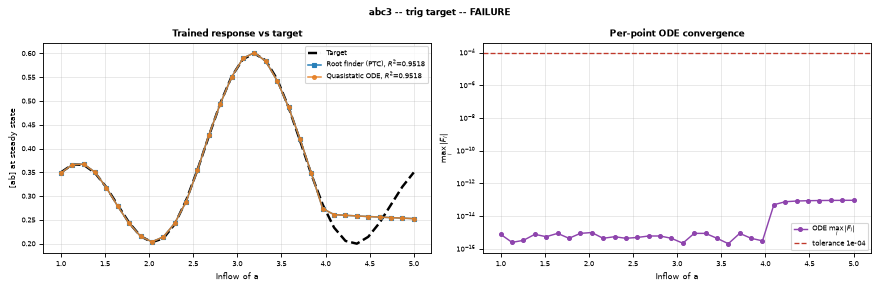

In [18]:
fig_v, (axa, axb) = plt.subplots(1, 2, figsize=(11, 3.6))

axa.plot(u_vals, target_vals, "k--", lw=2.2, label="Target")
axa.plot(u_vals, rootfind_preds, "s-", color="#2980b9", ms=3.5, lw=1.4,
         label=f"Root finder (PTC), $R^2$={r2_fit:.4f}")
axa.plot(u_vals, ode_readout, "o-", color="#e67e22", ms=3.5, lw=1.4, alpha=0.85,
         label=f"Quasistatic ODE, $R^2$={r2_ode:.4f}")
if (~ode_ok).any():
    axa.scatter(u_vals[~ode_ok], ode_readout[~ode_ok], marker="x", c="#c0392b",
                s=55, zorder=10, label="ODE not converged")
axa.set(xlabel=f"Inflow of {INPUT_SPECIES}",
        ylabel=f"[{READOUT_SPECIES}] at steady state",
        title="Trained response vs target")
axa.legend(fontsize=6); axa.grid(True, alpha=0.3)

axb.semilogy(u_vals, np.maximum(ode_residual, 1e-30), "o-", color="#8e44ad",
             ms=3.5, lw=1.3, label=r"ODE $\max_i|F_i|$")
axb.axhline(CONFIG["ode_res_tol"], color="#c0392b", ls="--", lw=1.2,
            label=f"tolerance {CONFIG['ode_res_tol']:.0e}")
axb.set(xlabel=f"Inflow of {INPUT_SPECIES}", ylabel=r"$\max_i|F_i|$",
        title="Per-point ODE convergence")
axb.legend(fontsize=6); axb.grid(True, alpha=0.3)

fig_v.suptitle(f"{topo['name']} -- {TARGET_KIND} target -- "
               f"{'SUCCESS' if success else 'FAILURE'}", fontweight="bold")
fig_v.tight_layout()
display(fig_v)
plt.close(fig_v)

## Reproducing the paper's studies

Both studies are loops over the knob cells; nothing below §5 changes.

**Scaling study (Fig. 2)** — how capacity grows with network size. Sweep **KNOB A** over
topologies and **KNOB B** over target complexity:

```python
for alphabet, max_length in [(["a","b"], 2), (["a","b"], 3), (["a","b","c"], 3), ...]:
    for H_harmonics in [1, 2, 4, 6, 8]:
        for seed in range(128):          # the ensemble at fixed complexity
            ...                          # rerun from KNOB A downward
```

**Freezing study (Fig. 3)** — which energetic class carries the capacity. Fix `abc3` and $H = 2$,
then sweep **KNOB C** over the seven non-empty subsets of `{dagger, mu, drive}` with `gamma`
frozen throughout:

```python
bins = [("drive",), ("mu",), ("dagger",),
        ("drive","mu"), ("dagger","drive"), ("dagger","mu"),
        ("dagger","drive","mu")]
for trainable in bins:
    TRAINABLE = {k: (k in trainable) for k in ("dagger","mu","drive")} | {"gamma": False}
```

Success rate per bin is the fraction of runs passing the §7 criterion. The published numbers —
60% for $D_\alpha$ alone, 8% for $\mu^\circ$, 0% for $G^\ddagger$, 73% for all three — come from
$7 \times 128 = 896$ runs. A single notebook run is one sample from that distribution, so do not
read too much into it either way: an individual failure is expected even in the strongest bin.

If you script this, the two things worth carrying over from the production harness are to
recreate `opt_m` / `opt_v` and `ss_cache` fresh for each run, and to record `exit_reason`
alongside the success flag — `solver_unstable` and `max_epoch` are different kinds of failure.

## Notes and caveats

**Where this notebook follows the code rather than the paper text.** This is a condensation of
the scripts that produced the published figures, so wherever the two disagree it reproduces the
code. The differences worth knowing about, all flagged in place above:

1. `INIT_SCALE = 0.6` (script default, what ran) vs $\mathcal N(0, 0.1)$ in the appendix.
2. The fit loss **sums** over grid points where the appendix writes $\tfrac1K\sum$; since the
   regularizers are means, this rescales the effective $\lambda$'s by $K$.
3. The condition number uses eigenvalue moduli, not singular values.
4. The abort threshold is 25% of grid points untrusted; the appendix says more than 50%.
5. Epoch-0 PTC seeds from $\max(c^{\mathrm{ext}}, 10^{-6})$, not from zeros.
6. SER uses $L^2$ norms for the timestep ratio; convergence uses $L^\infty$ throughout.

One thing here is *better* than production: the Solver Stiffness panel. In the production runs
its two data series were never populated, so it plotted flat zeros in every saved dashboard.
Here it shows real per-point condition numbers and spectral abscissae. That is a plotting fix
only — no training behaviour differs.

**Also in the paper but not implemented here:** the von Neumann elephant of Fig. 1(E), which
needs one input driving *two* readout species with the loss averaged over both. Everything else
in this notebook generalizes to it; only `lag_single` and the fit panels would change.

**Housekeeping.** The cell below closes the dashboard figure. Run it when you are done, or the
figure stays alive in the kernel.

In [19]:
plt.close(FIG)
print("dashboard figure closed")

dashboard figure closed
